In [74]:
# Customer Lifetime Value (LTV) Prediction Project (E-Commerce Dataset)

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from xgboost import XGBRegressor
from xgboost import plot_tree

In [76]:
# Step 2: Load Dataset (e.g., E-Commerce Dataset from Kaggle)
df = pd.read_csv('E-commerce_data.csv', encoding='ISO-8859-1')

In [77]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [78]:
# Step 3: Data Cleaning
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a total price column
# Quantity * UnitPrice = Total price for each item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [79]:
# Step 4: Feature Engineering (RFM)
# Define snapshot date as one day after the last invoice date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID to calculate Recency, Frequency, Monetary
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                       # Monetary (total spend)
})

# Rename columns appropriately
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# Calculate Average Order Value (AOV)
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

In [80]:
rfm.head(10)

,Recency,Frequency,Monetary,AOV
CustomerID,,,,
12346.0,326,2,0.00,0.000000
12347.0,2,7,4310.00,615.714286
12348.0,75,4,1797.24,449.310000
12349.0,19,1,1757.55,1757.550000
12350.0,310,1,334.40,334.400000
12352.0,36,11,1545.41,140.491818
12353.0,204,1,89.00,89.000000
12354.0,232,1,1079.40,1079.400000
12355.0,214,1,459.40,459.400000


In [81]:
# Step 5: Train-Test Split
X = rfm[['Recency', 'Frequency', 'AOV']]
print(X)
y = rfm['Monetary']
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


            Recency  Frequency          AOV
CustomerID                                 
12346.0         326          2     0.000000
12347.0           2          7   615.714286
12348.0          75          4   449.310000
12349.0          19          1  1757.550000
12350.0         310          1   334.400000
...             ...        ...          ...
18280.0         278          1   180.600000
18281.0         181          1    80.820000
18282.0           8          3    58.866667
18283.0           4         16   130.930000
18287.0          43          3   612.426667

[4372 rows x 3 columns]
CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: Monetary, Length: 4372, dtype: float64


In [82]:
# Step 6: Train the Model (XGBoost Regressor)
model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
# Step 7: Predict and Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 318.7457693762817
RMSE: 4828.86599529047
R² Score: 0.6684703570692925


In [86]:
# Step 8: Predict LTV for All Customers
rfm['Predicted_LTV'] = model.predict(rfm[['Recency', 'Frequency', 'AOV']])

In [87]:
# Step 9: Segment Customers Based on LTV
rfm['Segment'] = pd.qcut(rfm['Predicted_LTV'], q=3, labels=['Low', 'Medium', 'High'])
print(rfm)

            Recency  Frequency  Monetary          AOV  Predicted_LTV Segment
CustomerID                                                                  
12346.0         326          2      0.00     0.000000      14.091276     Low
12347.0           2          7   4310.00   615.714286    4282.941406    High
12348.0          75          4   1797.24   449.310000    1785.101562    High
12349.0          19          1   1757.55  1757.550000    1766.970825    High
12350.0         310          1    334.40   334.400000     340.605682     Low
...             ...        ...       ...          ...            ...     ...
18280.0         278          1    180.60   180.600000     181.757339     Low
18281.0         181          1     80.82    80.820000      79.971230     Low
18282.0           8          3    176.60    58.866667     188.257965     Low
18283.0           4         16   2094.88   130.930000    2097.615234    High
18287.0          43          3   1837.28   612.426667    1898.327637    High

In [88]:
# Step 10: Save Final Predictions to CSV
rfm[['Predicted_LTV', 'Segment']].to_csv('ltv_predictions_By_XGBoost.csv')

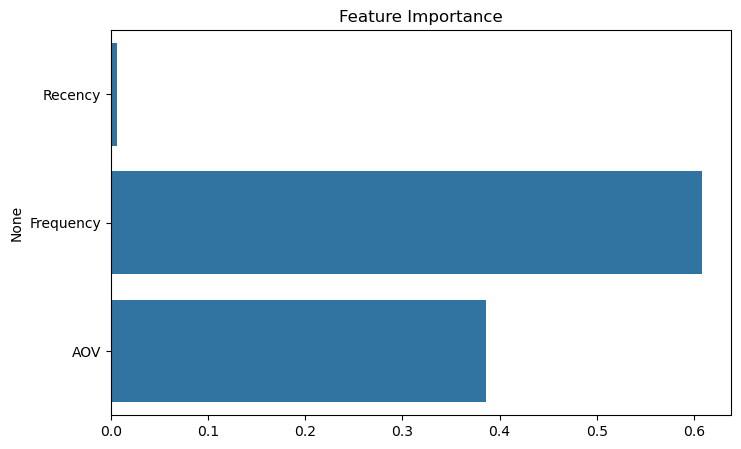

In [89]:
# Step 11: Visualizations
# Plot feature importances
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()

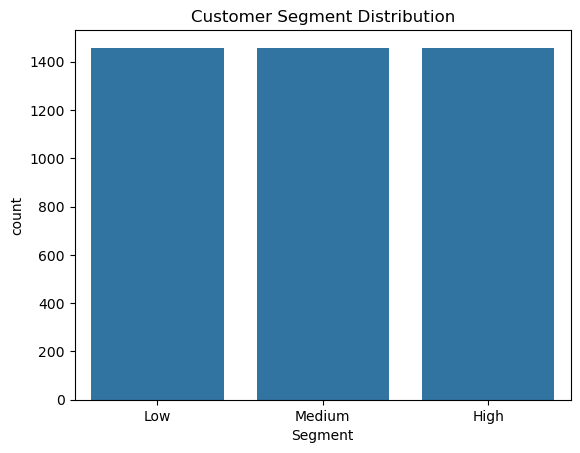

In [91]:
# Plot segment distribution
sns.countplot(data=rfm, x='Segment')
plt.title('Customer Segment Distribution')
plt.show()

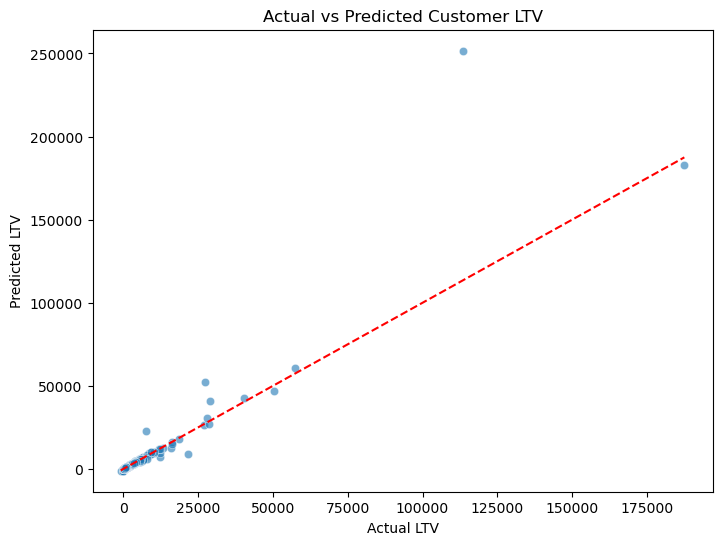

In [92]:
# Visualize Model Accuracy
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=preds, alpha=0.6)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted Customer LTV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Diagonal line
plt.show()

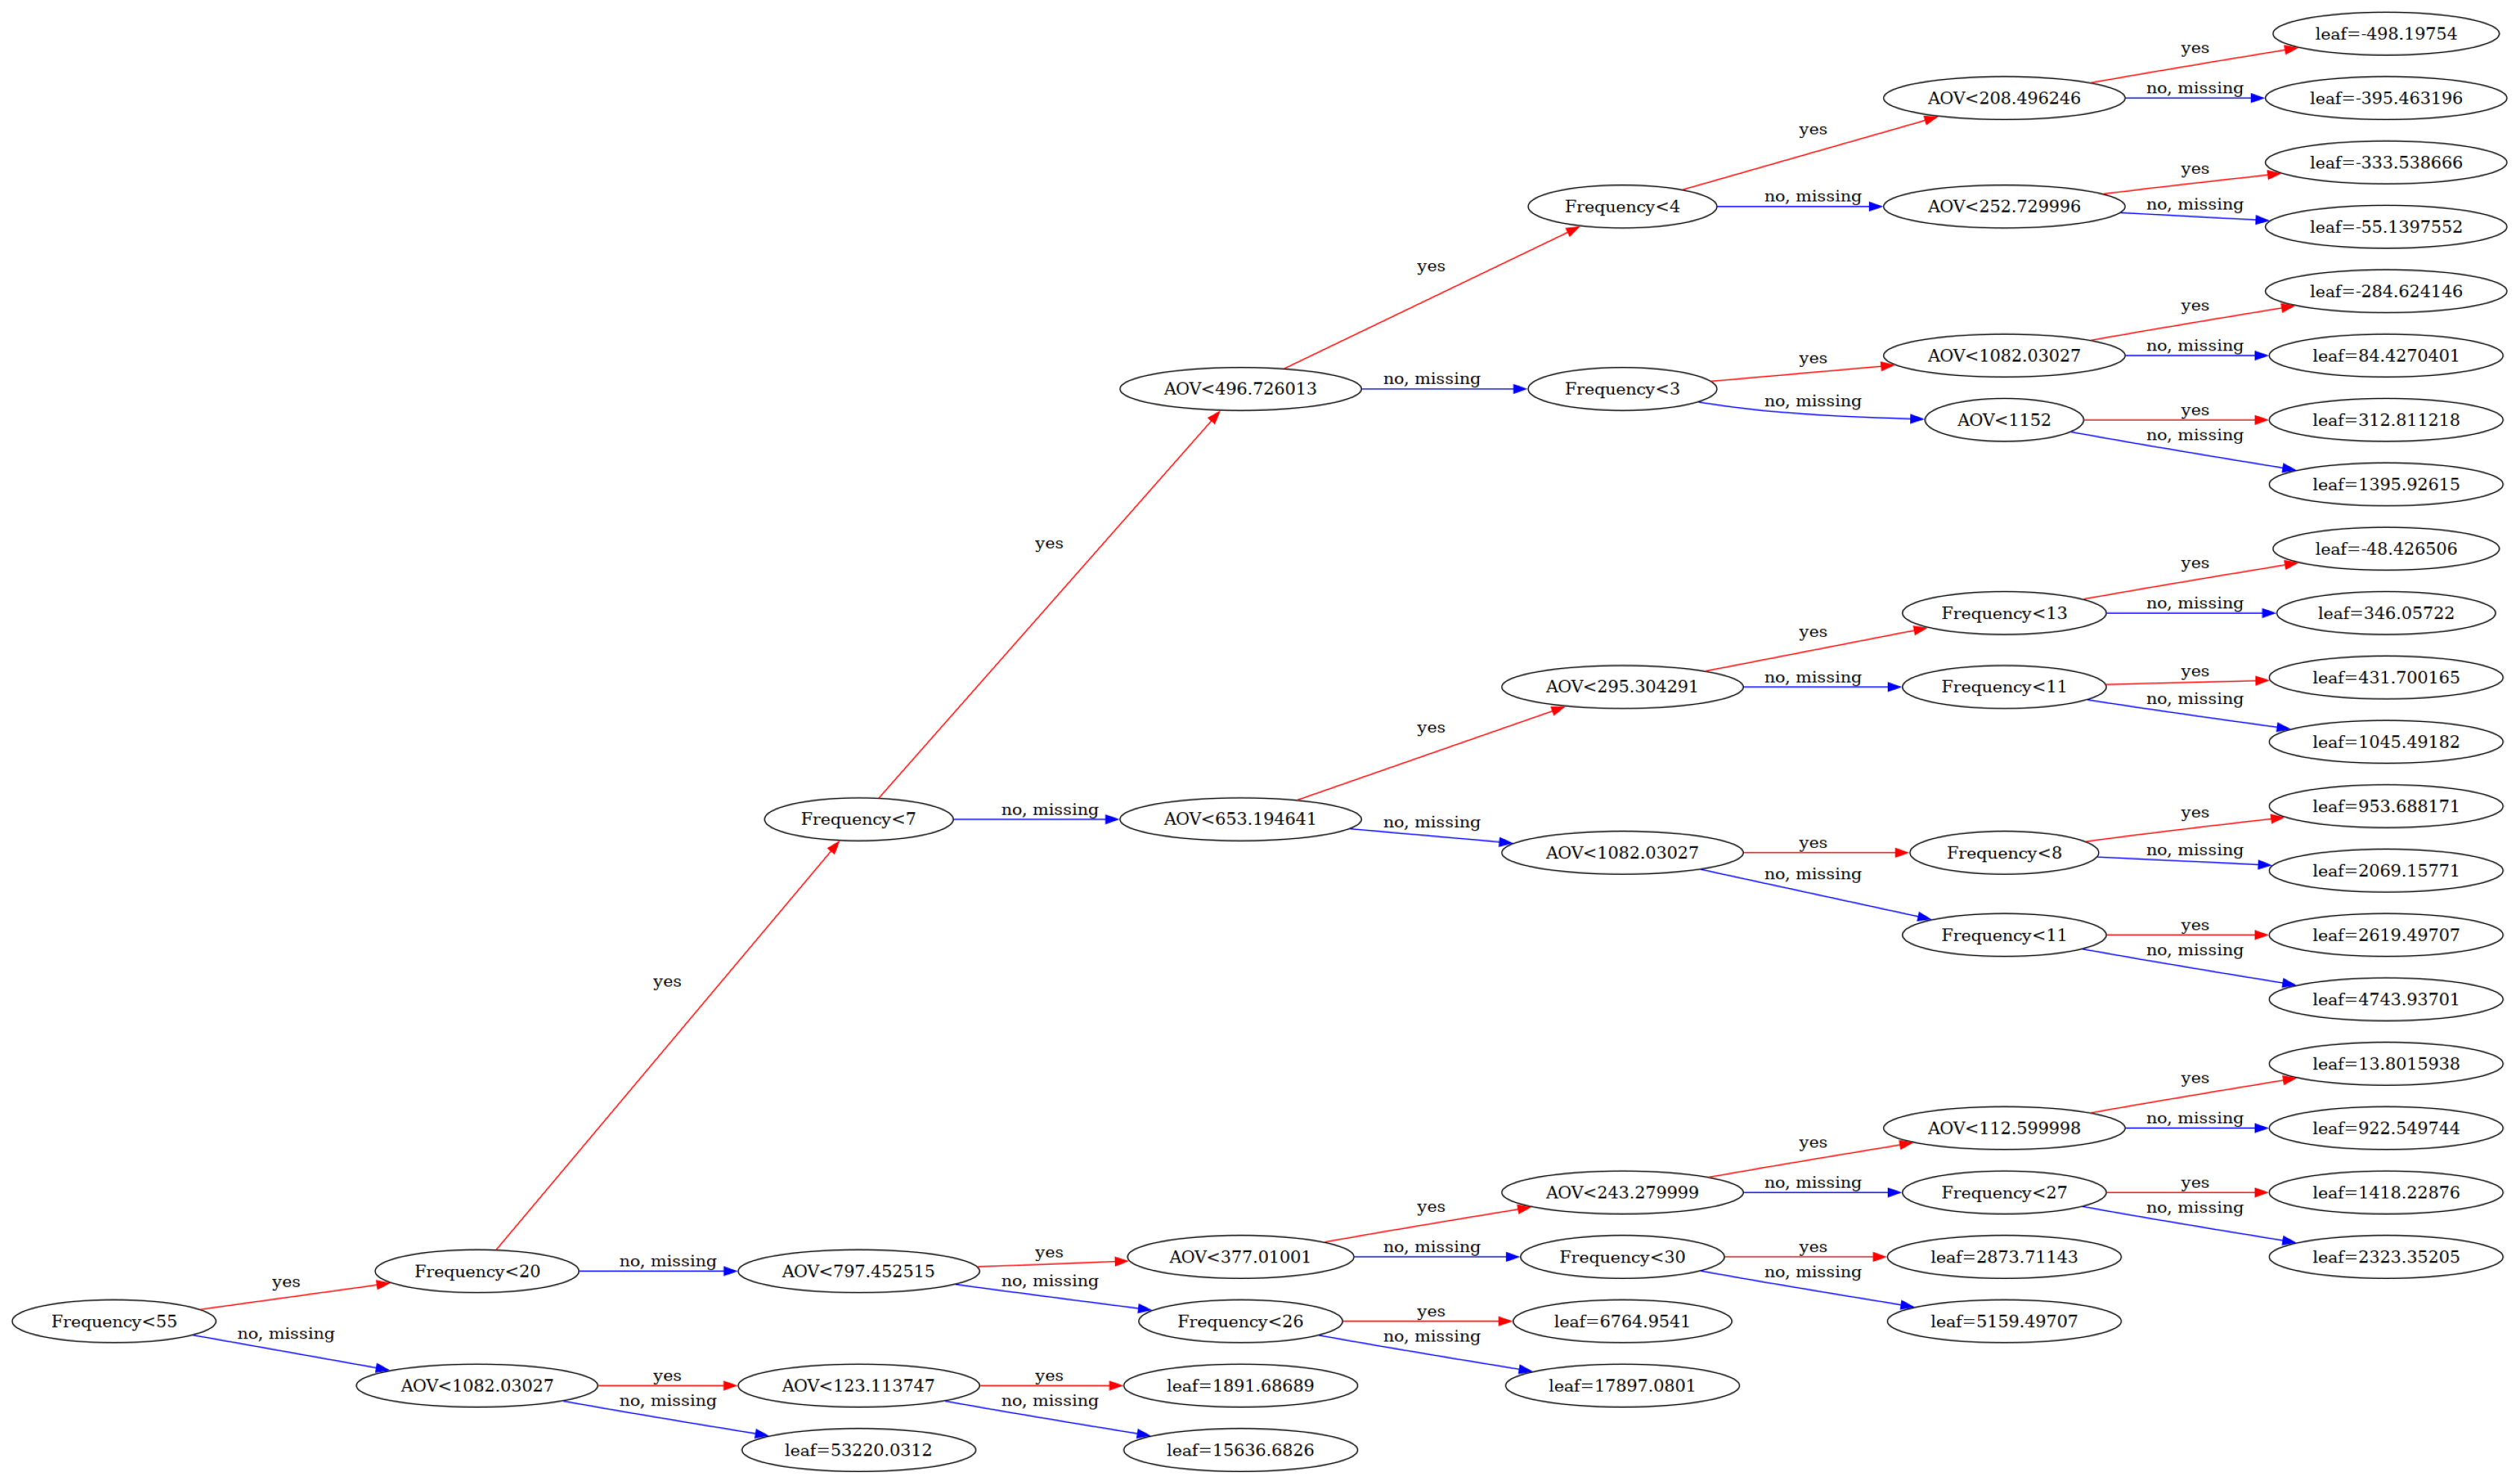

In [93]:
#  Visualizing Tree
fig, ax = plt.subplots(figsize=(100, 20))
plot_tree(model, tree_idx=0, rankdir='LR', ax=ax)
plt.tight_layout()
plt.show()

### IMPROVED Accuracy

## Customers with very high spending can skew the model. Applying a log transform helps by compressing the range.

In [94]:
# Filter to remove zero or negative Monetary values
rfm = rfm[rfm['Monetary'] > 0]

# Define features and log-transformed target
X = rfm[['Recency', 'Frequency', 'AOV']]
y = np.log1p(rfm['Monetary'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# Predict and convert back to original scale
preds_log = model.predict(X_test)
preds = np.expm1(preds_log)
y_actual = np.expm1(y_test)

# Evaluate
print("MAE:", mean_absolute_error(y_actual, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_actual, preds)))
print("R² Score:", r2_score(y_actual, preds))

MAE: 284.5574854683524
RMSE: 3544.341981013315
R² Score: 0.7778678534349603


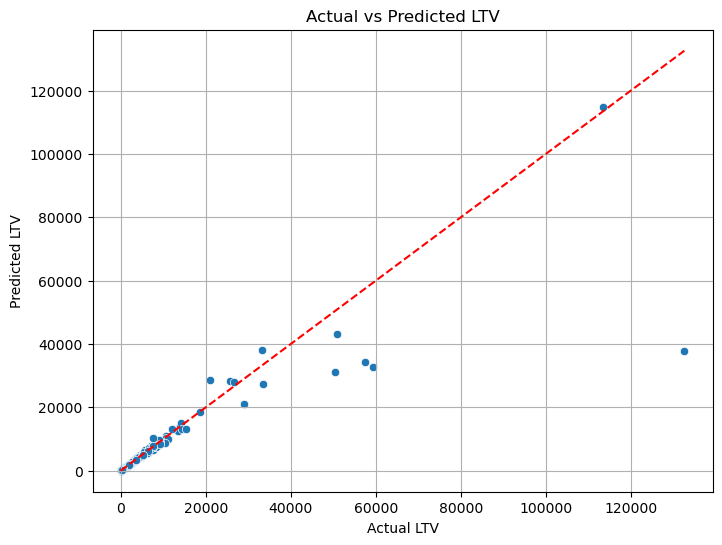

In [95]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_actual, y=preds)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')  # Perfect line
plt.xlabel('Actual LTV')
plt.ylabel('Predicted LTV')
plt.title('Actual vs Predicted LTV')
plt.grid(True)
plt.show()

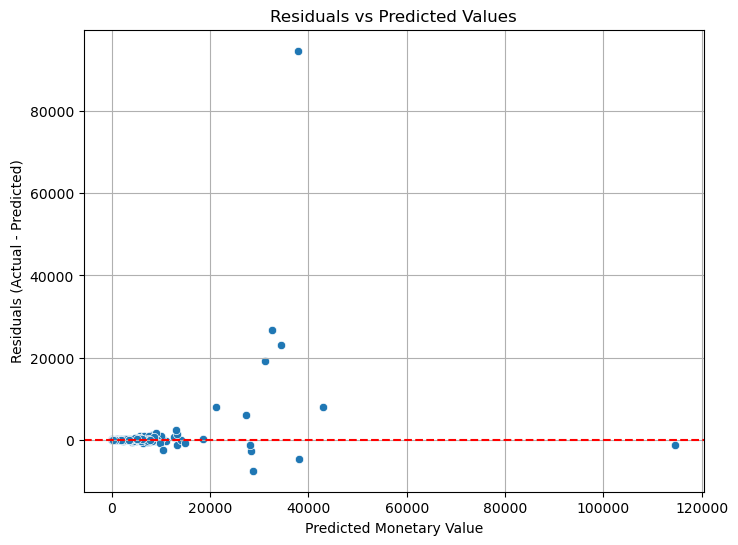

In [96]:
# Residuals plot
residuals = y_actual - preds

plt.figure(figsize=(8,6))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Monetary Value')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.grid(True)
plt.show()

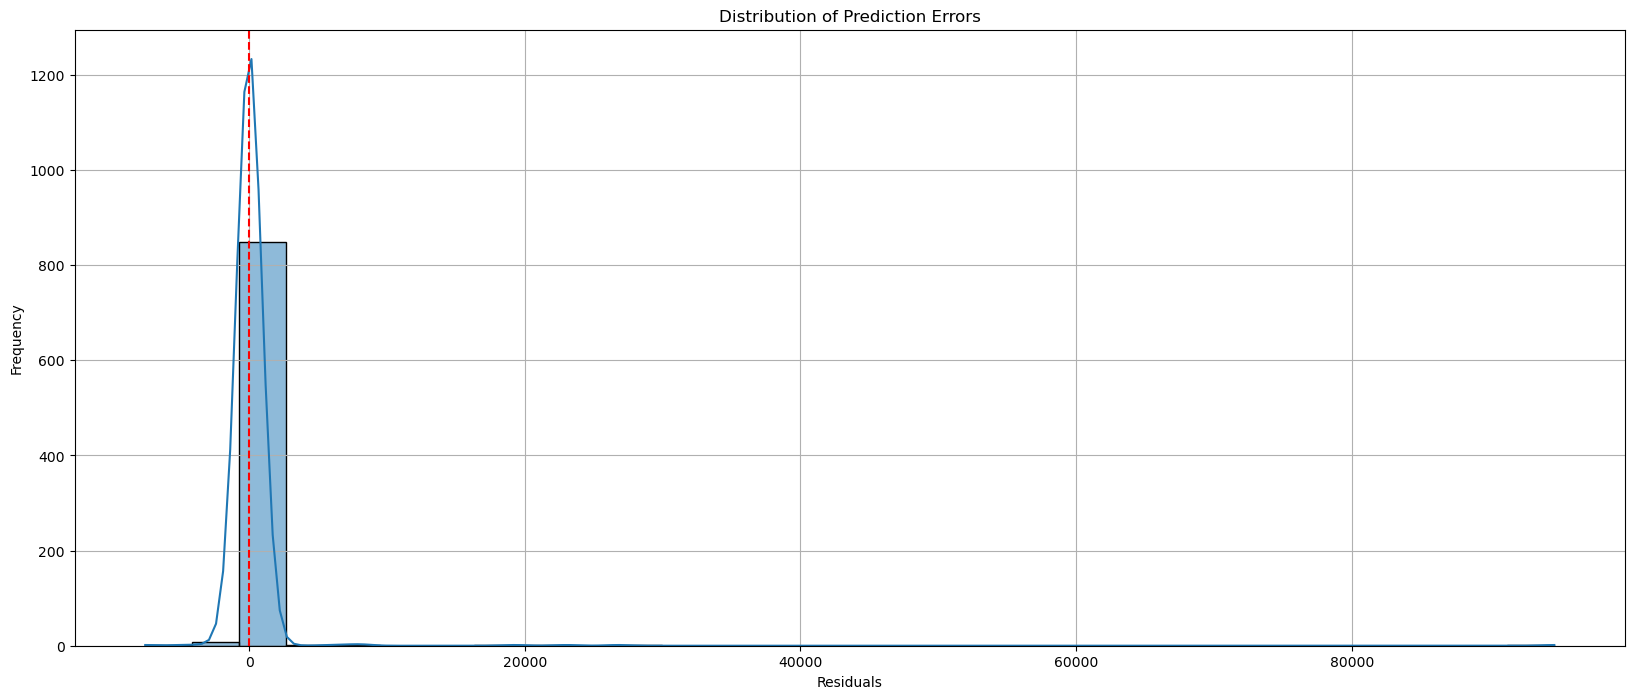

In [97]:
# Error distribution
plt.figure(figsize=(20,8))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()